# Week 1 Extension: Nearby Star Exploration

**Goal:** Repeat the week1 analysis restricted to nearby stars (d < 100 pc).

Nearby stars are better measured (higher parallax SNR) and less affected by Malmquist bias,
giving a cleaner view of the true stellar population around the Sun.

**Placeholder** — add analysis cells below.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from src.data_fetch import fetch_gaia_sample
from src.data_clean import clean_sample, add_features
from src import visualize

Status messages could not be retrieved


## Step 1: Fetch and Filter to Nearby Stars

Restrict to `distance_pc < 200` — within 200 parsecs (326 light-years). Nearby stars have high parallax SNR and are least affected by Malmquist bias.

In [5]:
import sys, os, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath('..'))

from src.data_fetch import fetch_gaia_sample
from src.data_clean import clean_sample, add_features

df = fetch_gaia_sample(top_n=10000)
clean = clean_sample(df)
clean = add_features(clean)

# Restrict to nearby stars — within 200 parsecs
nearby = clean[clean["distance_pc"] < 200].copy()
print(f"Nearby stars (d < 100 pc): {len(nearby):,}")

/var/folders/nd/dn4_4gx943b24pgx_l763l100000gn/T/ipykernel_12540/108672197.py:7: UserWarning: SSL certificate verification is disabled for this session. All HTTPS connections in this process will skip cert checks. Set SSL_CERT_FILE to your corporate CA bundle to avoid this.
  df = fetch_gaia_sample(top_n=10000)


Stars before cleaning: 10,000
Stars after cleaning:  2,432  (24.3% kept)
Nearby stars (d < 100 pc): 47


## Step 2: Distance Distribution

For a volume-limited sample we'd expect star counts to rise as d² (more volume at larger distances). Deviations from this reveal the survey completeness limit.

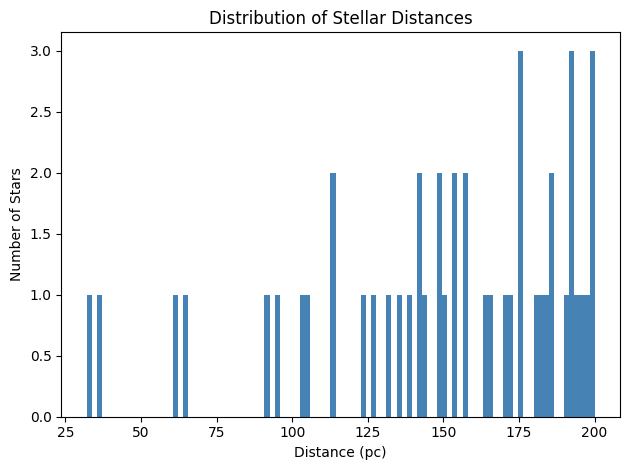

In [6]:
visualize.plot_distance_hist(nearby)

## Step 3: HR Diagram — Nearby Stars Only

With Malmquist bias reduced, the main sequence and white dwarf sequence are more faithfully represented.

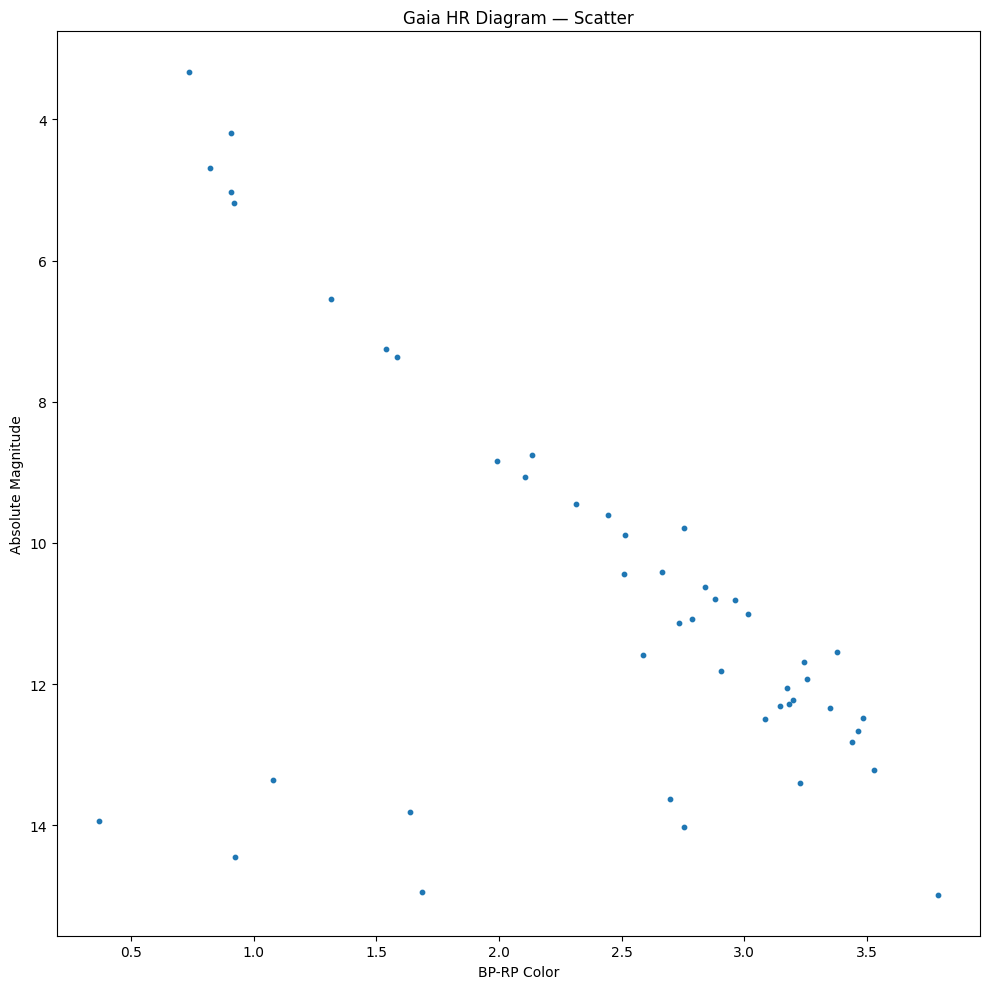

In [7]:
visualize.plot_hr_scatter(nearby)